# 2.1 Volatility

Asset price volatility is central to derivatives pricing. It is defined as a measure of price variability over a certain period of time. In essence, it describes the standard deviation of returns. There are different types of volatility: Historical, Implied, Forward. In most cases, we assume volatility to be constant, which is clearly not true and numerous studies have been dedicated to estimating this variable, both in academia and industry.

Volatility estimation by statistical means assumes equal weights to all returns measured over the period. We know that over 1-day, the mean return is small as compared to standard deviation. If we consider a simple m-period moving average, where \( $\sigma_n$ \) is the volatility of return on day \( $n$ \), then with \( $u \approx 0$ \), we have:

$$
\sigma_n^2 = \frac{1}{m} \sum_{i=1}^m u_{n-i}^2
$$

Where:
- \( $u$ \): return
- \( $\sigma^2$ \): variance

However, any large return within this \( $n$ \)-period will elevate the volatility until it drops out of the sample. Further, we observe volatility is mean-reverting and tends to vary about a long-term mean. To address this effect, we adopt the weighting schemes:

$$
\sigma_n^2 = \gamma \sigma + \sum_{i=1}^m \alpha_i u_{n-i}^2
$$

Or equivalently:

$$
\sigma_n^2 = \omega + \sum_{i=1}^m \alpha_i u_{n-i}^2
$$

Where:
- \( $\omega$ = $\gamma$ $\sigma$ \)
- The weights must sum to 1.

This is known as the **Autoregressive Conditional Heteroscedastic** model.


# 2.2 ARCH

**Autoregressive** models are a statistical technique involving a regression of lagged values where the model suggests that past values can
help forecast future values of the same variable. Within the model, a time series is the dependent variable and lagged values are the
independent variables.

The ARCH model, was originally developed by Robert Engle in 1982 to measure the dynamics of inflation uncertainty. **Conditional heteroskedasticity** refers to the notion that the next period’s volatility is conditional on the volatility in the current period as well as to the time
varying nature of volatility. However, given the volatility dynamics, this model fail to fully capture the persistence of volatility.

# 2.3 GARCH

To address the shortcoming, ARCH has been extended to a generalized framework where we add volatility as a forecasting feature by adding previous variance. This method is popularly known as the **Generalized ARCH or GARCH model**.

The model is represented as:

$$
\sigma_n^2 = \omega + \sum_{i=1}^p \alpha_i u_{n-i}^2 + \sum_{j=1}^q \beta_j \sigma_{n-j}^2
$$

Where \( p \) and \( q \) are lag lengths.

For GARCH(1,1), this can be simplified as:

$$
\sigma_n^2 = \omega + \alpha u_{n-1}^2 + \beta \sigma_{n-1}^2
$$

Where:
- \( \alpha + \beta < 1 \) 
- \( \gamma + \alpha + \beta = 1 \): weight applied to the long-term variance cannot be negative.

The long-run variance is given by:

$$
\frac{\omega}{1 - \alpha - \beta}
$$

The GARCH model is a way of specifying the dependence of the time-varying nature of volatility. The model incorporates changes in the fluctuations in volatility and tracks the persistence of volatility as it fluctuates around its long-term average and is exponentially weighted.

To model GARCH or the conditional volatility, we need to derive \( \omega \), \( \alpha \), \( \beta \) by maximizing the likelihood function.
ng the likelihood function.


## 2.3.1 Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

# Import matplotlib for visualization
import matplotlib
import matplotlib.pyplot as plt

# Plot settings
plt.style.use('ggplot')
matplotlib.rcParams['figure.figsize'] = [12.0, 8.0]
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['lines.linewidth'] = 2.0
import warnings
warnings.filterwarnings('ignore')

## 2.3.2 Retrieve Data

We will load the vol.csv files stored locally.

In [2]:
# Load locally stored data
df = pd.read_excel('SP500.xlsx', parse_dates=True, index_col=0)
df = df['2005':'2020']

# Check first and last 5 values
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1202.079956,1510800000
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1188.050049,1721000000
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1183.739990,1738900000
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1187.890015,1569100000
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1186.189941,1477900000
...,...,...,...,...,...,...
2020-12-24,3694.030029,3703.820068,3689.320068,3703.060059,3703.060059,1885090000
2020-12-28,3723.030029,3740.510010,3723.030029,3735.360107,3735.360107,3527460000
2020-12-29,3750.010010,3756.120117,3723.310059,3727.040039,3727.040039,3387030000


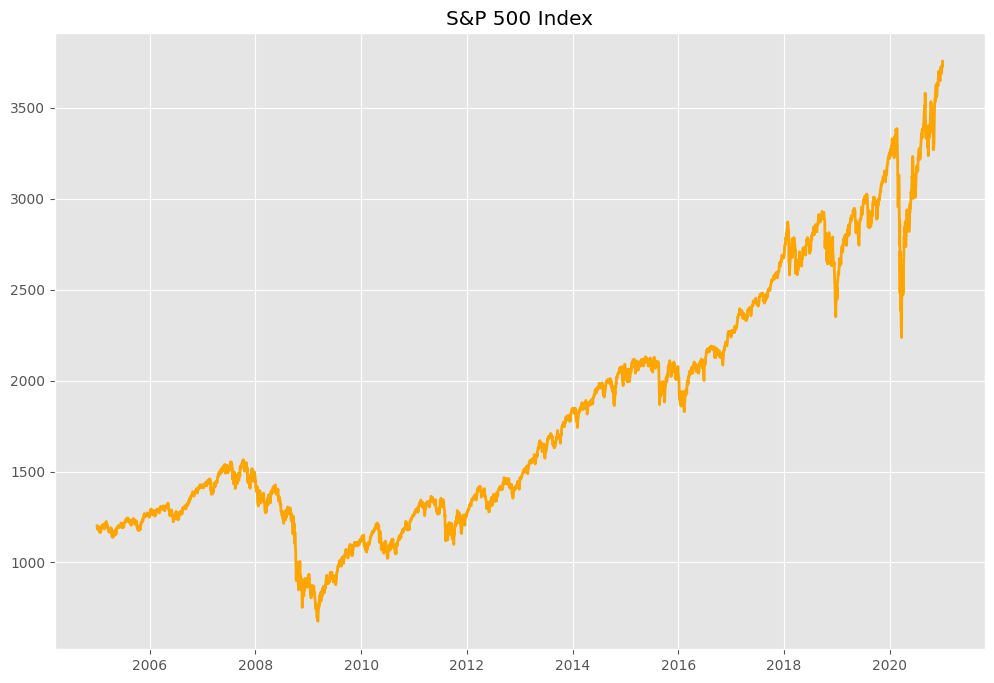

In [3]:
# Visualize FTSE 100 Index Price
plt.plot(df['Adj Close'], color='orange')
plt.title('S&P 500 Index')
plt.grid(True)

## 2.3.3 Calculate Log Returns

In [4]:
# Calculate daily returns
returns = np.log(df['Adj Close']).diff().fillna(0)

In [5]:
returns

Date
2005-01-03    0.000000
2005-01-04   -0.011740
2005-01-05   -0.003634
2005-01-06    0.003500
2005-01-07   -0.001432
                ...   
2020-12-24    0.003530
2020-12-28    0.008685
2020-12-29   -0.002230
2020-12-30    0.001341
2020-12-31    0.006418
Name: Adj Close, Length: 4028, dtype: float64

In [6]:
np.var(returns)

0.00015600867899146718

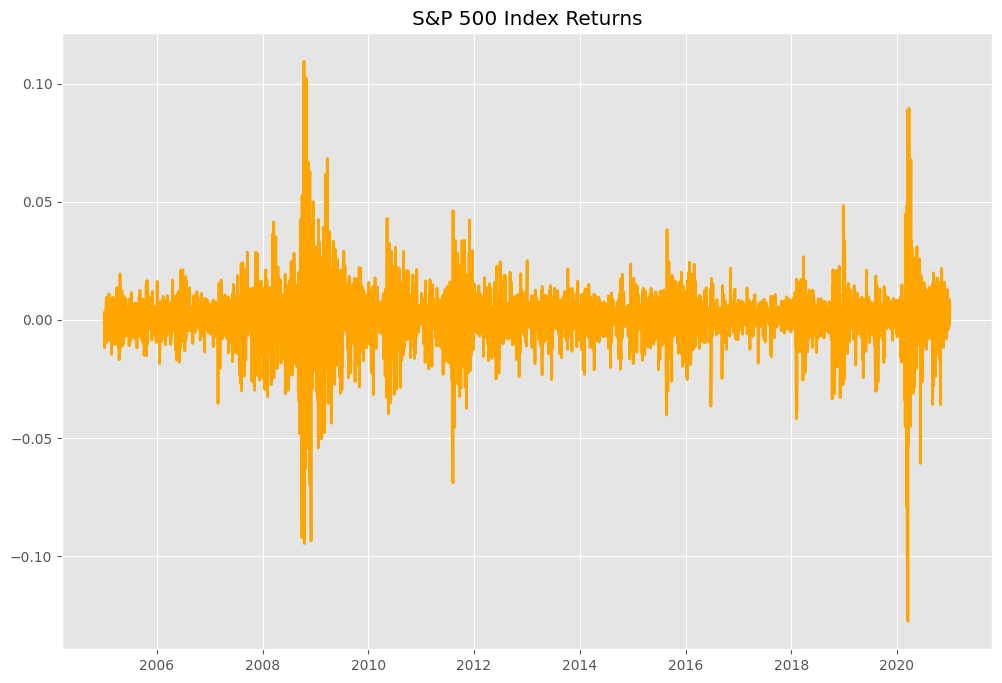

In [7]:
# Visualize FTSE 100 Index daily returns
plt.plot(returns, color='orange')
plt.title('S&P 500 Index Returns')
plt.grid(True)

# 2.4 Numerical Optimization

We will use Numerical optimization to maximize the likelihood estimation. Numerical optimization is typically implemented to find the minimum of a function rather than the maximum and the function to be minimize is called an objective function. For maximum likelihood estimation, we simply define a negative log likelihood as our objective function.

## 2.4.1 GARCH

Advantage of using a GARCH method when compared to EWMA is the inclusion of long term variance or volatility as a forecasting feature.

In [8]:
# GARCH(1,1) function
def garch(omega, alpha, beta, ret):
    length = len(ret)
    var = []
    
    for i in range(length):
        if i==0:
            var.append(omega/np.abs(1-alpha-beta))
        else:
            var.append(omega + alpha * ret[i-1]**2 + beta*var[i-1])
            
    return np.array(var)

In [9]:
garch(np.var(returns),0.1,0.8,returns)[:3]

array([0.00156009, 0.00140408, 0.00129305])

## 2.4.2 Maximum Likelihood Estimation

**Maximum Likelihood Estimation (MLE)** is a statistical method used for fitting the data to a model. When using MLE, we first assume a distribution (i.e., a parametric model) and then try to determine the model parameters. To estimate GARCH(1,1) parameters, we assume the distribution of returns conditional on variance is normally distributed.

We maximize:

$$
\sum_{i=1}^n \log \left[ \frac{1}{\sqrt{2 \pi \sigma_i^2}} e^{-\frac{(u_i - \mu)^2}{2 \sigma_i^2}} \right]
$$

to derive \( $\omega$ \), \( $\alpha$ \), and \( $\beta$ \).


In [10]:
# Log likelihood function
def likelihood(params, ret):
    length = len(ret)
    omega = params[0]
    alpha = params[1]
    beta = params[2]
    variance = garch(omega, alpha, beta, ret)
    llh = []
    
    for i in range(length):
        llh.append(np.log(norm.pdf(ret[i], 0, np.sqrt(variance[i]))))
    return -np.sum(np.array(llh))

In [11]:
likelihood((np.var(returns), 0.1, 0.8),returns)

-10252.88930248221

## 2.4.3 Optimization

Next, to optimize the GARCH parameters, we will use the **minimize** function from **scipy** optimization module. The objective function here is a function returning maximum log likelihood and the target variables are GARCH parameters.

Further, we use the **Nelder–Mead** method also known as downhill simplex method which is a commonly applied to numerical method to find the minimum or maximum of an objective function in a multidimensional space. The simplex algorithm is probably the simplest way to minimize a fairly well-behaved function. It requires only function evaluations and is a good choice for simple minimization problems. The downside to this method is it may take longer to find the minimum as it does not use any gradient evaluations.

In [12]:
# Specify optimization input
param = ['omega', 'alpha', 'beta']
initial_values = ((np.var(returns), 0.1, 0.8))

In [13]:
res = minimize(likelihood, initial_values, args = returns, method='Nelder-Mead', options={'disp':False})

In [14]:
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -13218.766120041719
             x: [ 2.646e-06  1.316e-01  8.451e-01]
           nit: 104
          nfev: 185
 final_simplex: (array([[ 2.646e-06,  1.316e-01,  8.451e-01],
                       [ 2.646e-06,  1.315e-01,  8.452e-01],
                       [ 2.649e-06,  1.316e-01,  8.451e-01],
                       [ 2.645e-06,  1.316e-01,  8.451e-01]]), array([-1.322e+04, -1.322e+04, -1.322e+04, -1.322e+04]))

In [15]:
res['x']

array([2.64648957e-06, 1.31570491e-01, 8.45116052e-01])

In [16]:
# GARCH parameters
dict(zip(param,np.around(res['x']*100,4)))

{'omega': 0.0003, 'alpha': 13.157, 'beta': 84.5116}

In [17]:
# Parameters
omega = res['x'][0]
alpha = res['x'][1]
beta = res['x'][2]

# Variance
var = garch(res['x'][0],res['x'][1],res['x'][2],returns)

# Annualised conditional volatility
ann_vol = np.sqrt(var*252) * 100
ann_vol

array([16.91344308, 15.76156409, 16.19618915, ..., 10.54227306,
       10.11155528,  9.67846785])

## 2.4.4 Visualize Volatility

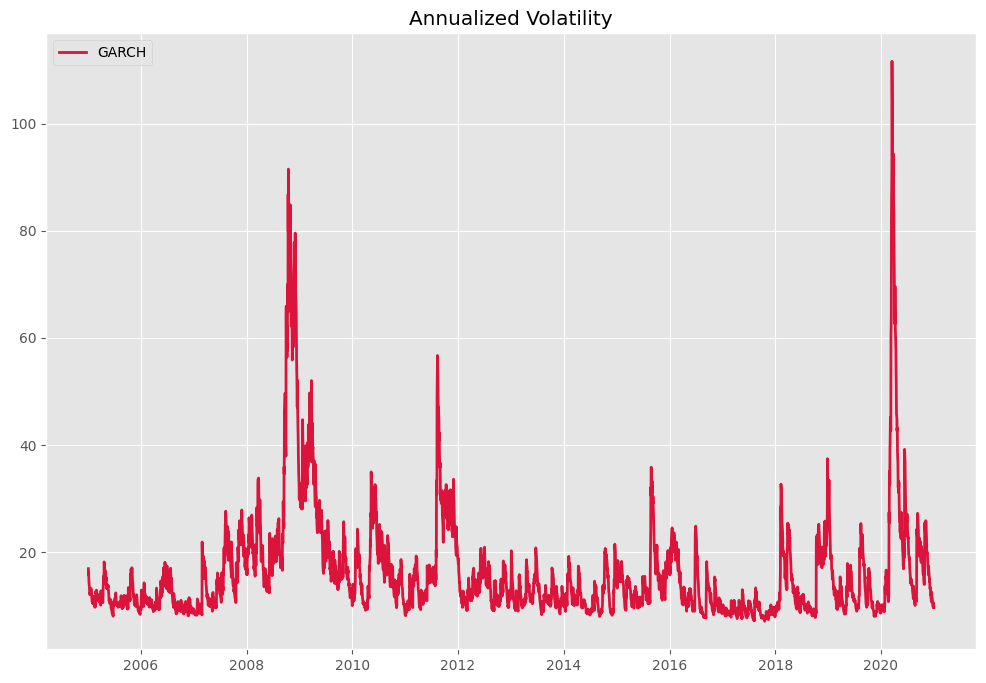

In [18]:
# Visualise GARCH volatility and VIX
plt.title('Annualized Volatility')
plt.plot(returns.index, ann_vol, color='crimson', label='GARCH')
plt.legend(loc=2)
plt.grid(True)

## 2.4.5 N-day Forecast

Extending the GARCH(1,1) model to forecast future volatility, we can derive the \( n \)-days ahead forecast using the following equation:

$$
E[\sigma_{n+k}^2] = \sigma^2 + (\alpha + \beta)^k (\sigma_n^2 - \sigma^2)
$$

Where:
- \( \sigma^2 \) is the long-run variance.
- \( \alpha \) and \( \beta \) are GARCH parameters.

We know that volatility has the tendency to revert to its long-run range. And, \( \alpha + \beta < 1 \) in GARCH(1,1), hence when \( k \) gets larger, the second term gets smaller and the forecast tends towards the long-term variance.


In [19]:
# Calculate N-day forecast
longrun_variance = omega/(1-alpha-beta)
fvar = []

for i in range(1,732):
    fvar.append(longrun_variance + (alpha+beta)**i * (var[-1] - longrun_variance))
var = np.array(fvar)

In [20]:
# Verify first 10 values
var[:10]

array([3.89516104e-05, 4.06900033e-05, 4.23878682e-05, 4.40461501e-05,
       4.56657716e-05, 4.72476342e-05, 4.87926181e-05, 5.03015830e-05,
       5.17753688e-05, 5.32147956e-05])

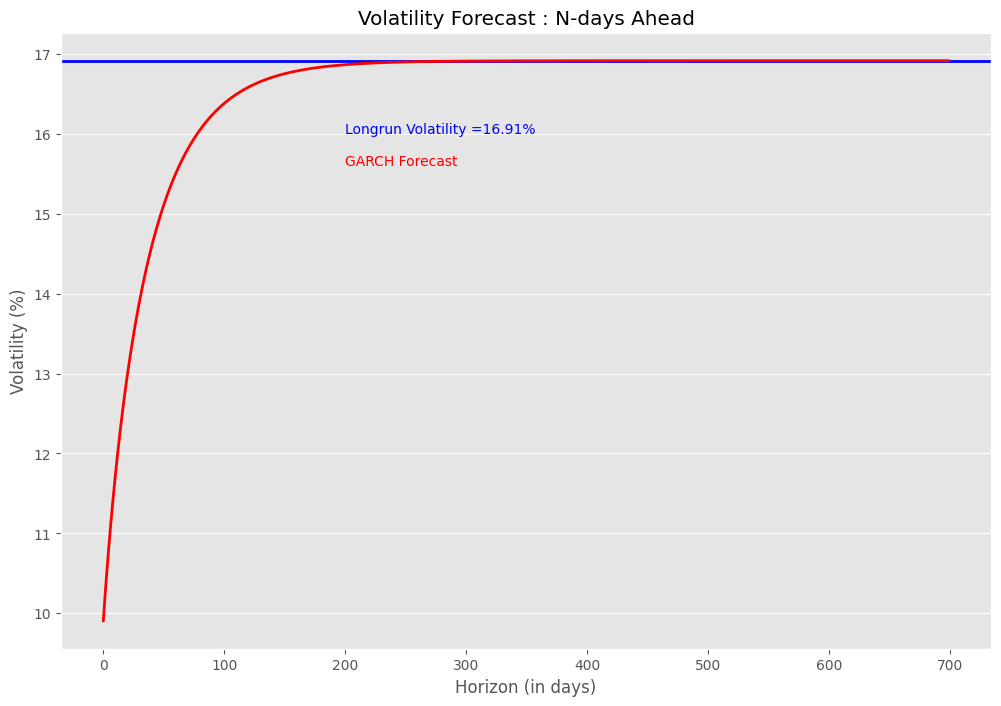

In [21]:
# Plot volatility forecast over different time horizon
plt.axhline(y=np.sqrt(longrun_variance*252)*100, color='blue')
plt.plot(np.sqrt(var[:700]*252)*100, color='red')
plt.xlabel('Horizon (in days)')
plt.ylabel('Volatility (%)')
plt.annotate('GARCH Forecast', xy=(200,15.60), color='red')
plt.annotate('Longrun Volatility =' + str(np.around(np.sqrt(longrun_variance*252)*100,2)) + '%', xy=(200,16), color='blue')
plt.title('Volatility Forecast : N-days Ahead')
plt.grid(axis='x')

# 2.5 ARCH Toolbox

ARCH is one of the popular tools used for financial econometrics, written in Python - with Cython and/or Numba used to improve performance. We will now use **arch_model** to fit our GARCH model using this package.

In [22]:
# Import arch library
from arch import arch_model

In [23]:
# Mean zero
g1 = arch_model(returns, vol='GARCH', mean='Zero', p=1, o=0, q=1, dist='Normal')

In [24]:
model = g1.fit()

Iteration:      1,   Func. Count:      4,   Neg. LLF: -13200.468233095027
Optimization terminated successfully    (Exit mode 0)
            Current function value: -13200.468219635568
            Iterations: 5
            Function evaluations: 4
            Gradient evaluations: 1


In [25]:
# Model output
print(model)

                       Zero Mean - GARCH Model Results                        
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                13200.5
Distribution:                  Normal   AIC:                          -26394.9
Method:            Maximum Likelihood   BIC:                          -26376.0
                                        No. Observations:                 4028
Date:                Sun, Mar 09 2025   Df Residuals:                     4028
Time:                        18:43:02   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      3.1218e-06  8.435e-10   3700.798      0.000 [3.

In [26]:
# Model params
model.params

omega       0.000003
alpha[1]    0.200000
beta[1]     0.780000
Name: params, dtype: float64

In [27]:
# Model Confidence Interval
model.conf_int(alpha=.05)

,lower,upper
omega,0.000003,0.000003
alpha[1],0.180384,0.219616
beta[1],0.764147,0.795853


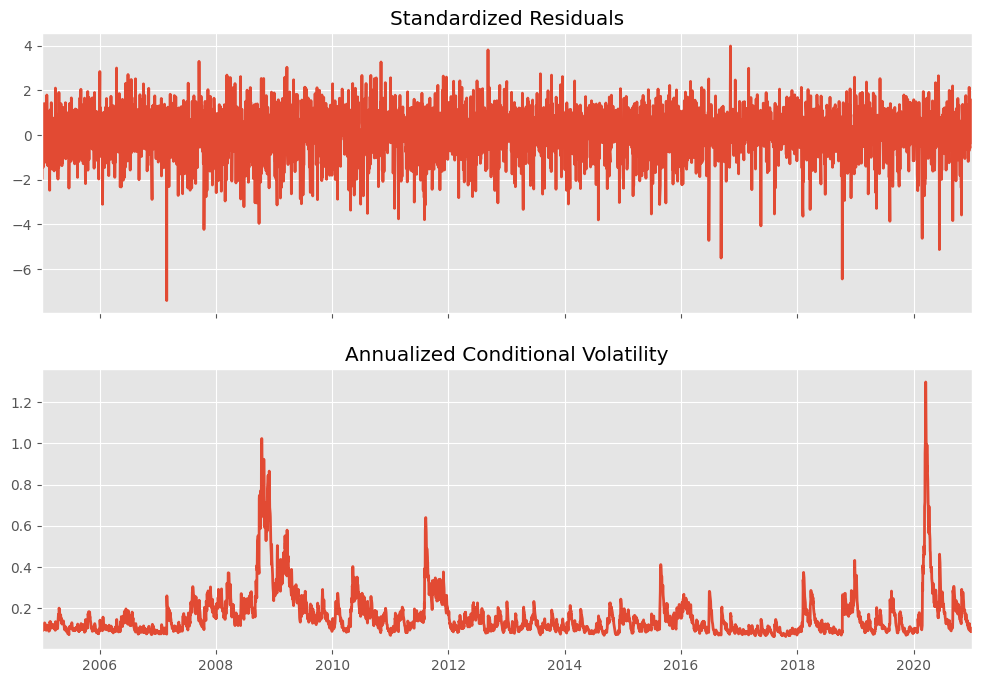

In [28]:
# Plot annualised vol
fig = model.plot(annualize='D')

In [29]:
model.conditional_volatility*np.sqrt(252)

Date
2005-01-03    0.101752
2005-01-04    0.094140
2005-01-05    0.121020
2005-01-06    0.113473
2005-01-07    0.106993
                ...   
2020-12-24    0.089681
2020-12-28    0.087682
2020-12-29    0.102882
2020-12-30    0.096402
2020-12-31    0.090145
Name: cond_vol, Length: 4028, dtype: float64

In [30]:
# Forecast for next 5 days
model_forecast = model.forecast(horizon=60)

In [31]:
# Subsume forecast values into a dataframe
forecast_df = pd.DataFrame(np.sqrt(model_forecast.variance.dropna().T *252)*100)
forecast_df.columns = ['Cond_Vol']
forecast_df.head()

,Cond_Vol
h.01,9.592299
h.02,9.901456
h.03,10.195338
h.04,10.475347
h.05,10.742677


In [32]:
# long run variance from model forecast
lrv = model.params[0]/(1-model.params[1]-model.params[2])
# long run variance
np.sqrt(lrv*252)*100

19.83288888360759

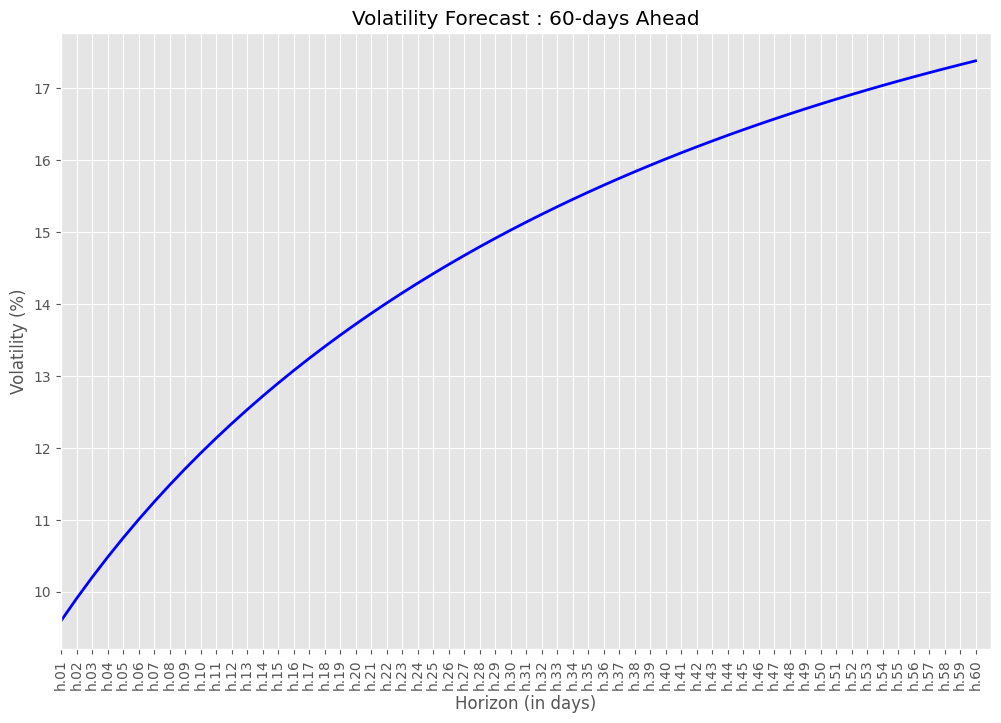

In [33]:
# Plot volatility forecast over a 60-day horizon
plt.plot(forecast_df, color='blue')
plt.xlim(0,60)
plt.xticks(rotation=90)
plt.xlabel('Horizon (in days)')
plt.ylabel('Volatility (%)')
plt.title('Volatility Forecast : 60-days Ahead');
plt.grid(True)

# References

- Scipy
- Arch